In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('bank-additional-full.csv', sep=';')

print(" Shape (Rows, Columns):", df.shape)
print("\n First 5 Rows:\n", df.head())
print("\n Data Types & Non-Null Counts:\n")
df.info()
print("\n Numerical Columns Summary:\n", df.describe())
print("\n Missing Values per Column:\n", df.isnull().sum())

 Shape (Rows, Columns): (41188, 21)

 First 5 Rows:
    age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# === 1. Target Variable Encode Karna (if not already done) ===
if df['y'].dtype == 'object':
    df['y'] = df['y'].map({'yes': 1, 'no': 0})
    print(" Target variable encoded: 'yes'→1, 'no'→0")
else:
    print(" Target already encoded (numeric)")

print("Sample values:", df['y'].value_counts())

# === 2. Categorical Columns Identify Karna ===
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n Categorical columns found: {categorical_cols}")

# === 3. Safe Removal of 'y' if it exists in list ===
if 'y' in categorical_cols:
    categorical_cols.remove('y')
    print(" Removed 'y' from categorical columns")

# === 4. Binary vs Multi-class Columns Separate Karna ===
# Pehle check karein ke kaunse columns actually exist karte hain
binary_cols = [col for col in ['default', 'housing', 'loan', 'poutcome'] if col in categorical_cols]
multi_class_cols = [col for col in categorical_cols if col not in binary_cols]

print(f"\n Binary columns (Label Encoding): {binary_cols}")
print(f" Multi-class columns (One-Hot Encoding): {multi_class_cols}")

# === 5. Label Encoding for Binary Columns ===
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f" {col} encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# === 6. One-Hot Encoding for Multi-class Columns ===
df_encoded = pd.get_dummies(df, columns=multi_class_cols, drop_first=True)
print(f"\n One-Hot Encoding complete! New shape: {df_encoded.shape}")
print("   (drop_first=True ne multicollinearity se bachaya)")

# === 7. Features (X) aur Target (y) Alag Karna ===
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# === 8. Train-Test Split (80-20) ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n Train-Test Split Complete:")
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Testing set: {X_test.shape[0]} samples")
print(f"   Features: {X_train.shape[1]} columns")
print(f"   Target distribution in train: {y_train.value_counts(normalize=True).to_dict()}")
print(f"   Target distribution in test: {y_test.value_counts(normalize=True).to_dict()}")

 Target already encoded (numeric)
Sample values: y
0    36548
1     4640
Name: count, dtype: int64

 Categorical columns found: ['job', 'marital', 'education', 'contact', 'month', 'day_of_week']

 Binary columns (Label Encoding): []
 Multi-class columns (One-Hot Encoding): ['job', 'marital', 'education', 'contact', 'month', 'day_of_week']

 One-Hot Encoding complete! New shape: (41188, 50)
   (drop_first=True ne multicollinearity se bachaya)

 Train-Test Split Complete:
   Training set: 32950 samples
   Testing set: 8238 samples
   Features: 49 columns
   Target distribution in train: {0: 0.8873444613050075, 1: 0.11265553869499241}
   Target distribution in test: {0: 0.8873512988589464, 1: 0.11264870114105366}


 STEP 3: MODEL TRAINING STARTED

 Training Logistic Regression...


C:\Users\haris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


 Logistic Regression trained!

 Training Random Forest...
 Random Forest trained!

 Making predictions...
 Predictions complete!

 EVALUATING MODELS ON TEST DATA

 LOGISTIC REGRESSION Performance
Accuracy:  0.8625
Precision: 0.4460
Recall:    0.9116
F1-Score:  0.5989
ROC-AUC:   0.9432

 Classification Report:
              precision    recall  f1-score   support

  No Deposit       0.99      0.86      0.92      7310
     Deposit       0.45      0.91      0.60       928

    accuracy                           0.86      8238
   macro avg       0.72      0.88      0.76      8238
weighted avg       0.93      0.86      0.88      8238


 Confusion Matrix:
           Predicted No   Predicted Yes
Actual No       6259          1051
Actual Yes        82           846

 RANDOM FOREST Performance
Accuracy:  0.8699
Precision: 0.4615
Recall:    0.9289
F1-Score:  0.6166
ROC-AUC:   0.9497

 Classification Report:
              precision    recall  f1-score   support

  No Deposit       0.99      0.86 

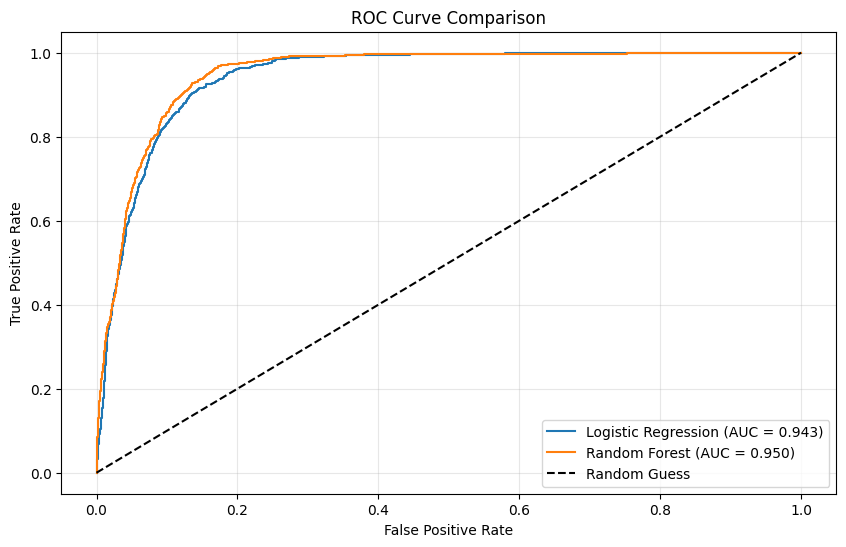


 FINAL COMPARISON
Metric          Logistic Reg    Random Forest   Winner    
------------------------------------------------------------
Accuracy        0.8625          0.8699          Random Forest
F1-Score        0.5989          0.6166          Random Forest
ROC-AUC         0.9432          0.9497          Random Forest

 Step 3 Complete! Models trained and evaluated.


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             roc_curve, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print(" STEP 3: MODEL TRAINING STARTED")
print("="*60)

# === 1. Logistic Regression Train Karna ===
print("\n Training Logistic Regression...")
log_model = LogisticRegression(
    max_iter=1000,      # Zyada iterations for convergence
    random_state=42,
    class_weight='balanced'  # Imbalanced data ko handle karne ke liye
)
log_model.fit(X_train, y_train)
print(" Logistic Regression trained!")

# === 2. Random Forest Train Karna ===
print("\n Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees
    max_depth=10,       # Har tree max 10 levels tak
    random_state=42,
    class_weight='balanced',  # Imbalanced data handling
    n_jobs=-1           # Saare CPU cores use kare
)
rf_model.fit(X_train, y_train)
print(" Random Forest trained!")

# === 3. Predictions ===
print("\n Making predictions...")
# Logistic Regression predictions
log_pred_train = log_model.predict(X_train)
log_pred_test = log_model.predict(X_test)
log_proba_test = log_model.predict_proba(X_test)[:, 1]  # Probability of "yes"

# Random Forest predictions
rf_pred_train = log_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)
rf_proba_test = rf_model.predict_proba(X_test)[:, 1]

print(" Predictions complete!")

# === 4. Evaluation Function ===
def evaluate_model(model_name, y_true, y_pred, y_proba=None):
    """Model ko comprehensively evaluate karna"""
    print(f"\n{'='*60}")
    print(f" {model_name} Performance")
    print(f"{'='*60}")
    
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    
    if y_proba is not None:
        print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    
    print(f"\n Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Deposit', 'Deposit']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n Confusion Matrix:")
    print(f"           Predicted No   Predicted Yes")
    print(f"Actual No      {cm[0,0]:5d}         {cm[0,1]:5d}")
    print(f"Actual Yes     {cm[1,0]:5d}         {cm[1,1]:5d}")
    
    return cm

# === 5. Models Evaluate Karna ===
print("\n" + "="*60)
print(" EVALUATING MODELS ON TEST DATA")
print("="*60)

cm_log = evaluate_model("LOGISTIC REGRESSION", y_test, log_pred_test, log_proba_test)
cm_rf = evaluate_model("RANDOM FOREST", y_test, rf_pred_test, rf_proba_test)

# === 6. ROC Curve Comparison ===
print("\n Plotting ROC Curves...")
fpr_log, tpr_log, _ = roc_curve(y_test, log_proba_test)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba_test)

plt.figure(figsize=(10, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, log_proba_test):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_proba_test):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# === 7. Model Comparison Summary ===
print("\n" + "="*60)
print(" FINAL COMPARISON")
print("="*60)
print(f"{'Metric':<15} {'Logistic Reg':<15} {'Random Forest':<15} {'Winner':<10}")
print("-"*60)

metrics = {
    'Accuracy': (accuracy_score(y_test, log_pred_test), accuracy_score(y_test, rf_pred_test)),
    'F1-Score': (f1_score(y_test, log_pred_test), f1_score(y_test, rf_pred_test)),
    'ROC-AUC': (roc_auc_score(y_test, log_proba_test), roc_auc_score(y_test, rf_proba_test))
}

for metric, (log_val, rf_val) in metrics.items():
    winner = "Logistic" if log_val > rf_val else "Random Forest"
    print(f"{metric:<15} {log_val:<15.4f} {rf_val:<15.4f} {winner:<10}")

print("\n Step 3 Complete! Models trained and evaluated.")

 STEP 4: MODEL INTERPRETABILITY (SHAP)

📊 Calculating SHAP values...
(Ye thora time le sakta hai, sabar karein)
✅ SHAP values calculated!

📈 Generating SHAP Summary Plot...


<Figure size 1200x600 with 0 Axes>

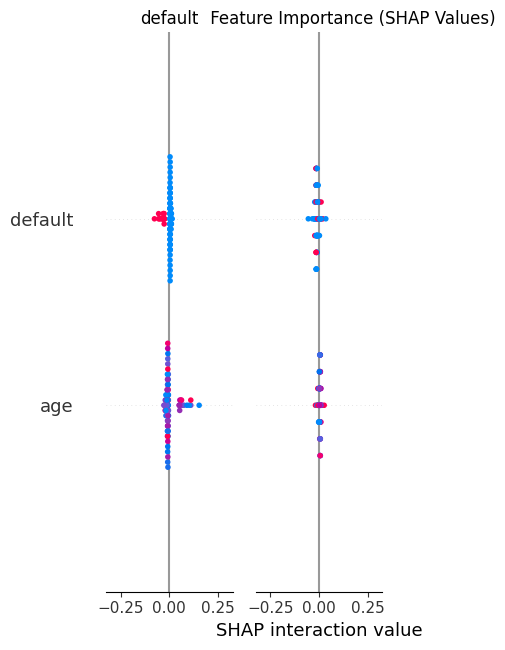


📈 Generating SHAP Beeswarm Plot...


<Figure size 1200x800 with 0 Axes>

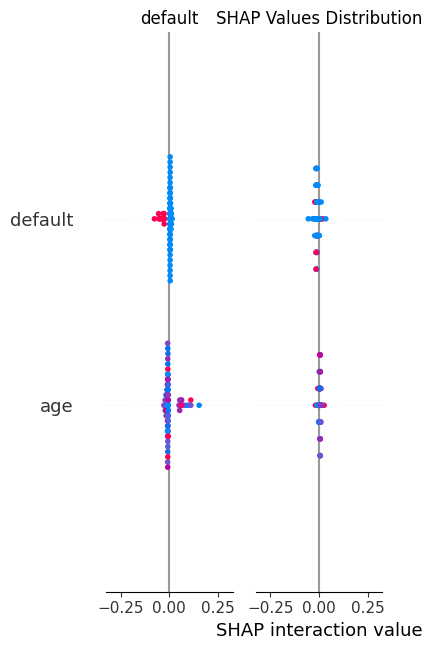


🔍 Analyzing Individual Predictions...

📋 Sample #0
Actual: NO
Predicted: NO
Probability of YES: 10.45%

🎯 Top 5 Features influencing this prediction:
   • emp.var.rate: ↓ decreases chance of YES (SHAP value: -0.201)
   • poutcome: ↑ increases chance of YES (SHAP value: 0.201)
   • job_self-employed: ↓ decreases chance of YES (SHAP value: -0.062)
   • job_retired: ↑ increases chance of YES (SHAP value: 0.062)
   • marital_married: ↓ decreases chance of YES (SHAP value: -0.056)

📋 Sample #15
Actual: NO
Predicted: NO
Probability of YES: 7.86%

🎯 Top 5 Features influencing this prediction:
   • emp.var.rate: ↓ decreases chance of YES (SHAP value: -0.105)
   • poutcome: ↑ increases chance of YES (SHAP value: 0.105)
   • marital_married: ↓ decreases chance of YES (SHAP value: -0.051)
   • job_unknown: ↑ increases chance of YES (SHAP value: 0.051)
   • marital_unknown: ↓ decreases chance of YES (SHAP value: -0.049)

📋 Sample #30
Actual: NO
Predicted: NO
Probability of YES: 12.84%

🎯 Top 5 Fe

In [18]:
import shap
import matplotlib.pyplot as plt

print("="*60)
print(" STEP 4: MODEL INTERPRETABILITY (SHAP)")
print("="*60)

# === 1. SHAP for Random Forest ===
print("\n📊 Calculating SHAP values...")
print("(Ye thora time le sakta hai, sabar karein)")

# SHAP explainer create karna
explainer = shap.TreeExplainer(rf_model)

# Test data ke liye SHAP values calculate karna
# Pehle 100 samples lete hain (fast computation ke liye)
shap_values = explainer.shap_values(X_test.iloc[:100])

print("✅ SHAP values calculated!")

# === 2. Summary Plot (Bar Chart) ===
print("\n📈 Generating SHAP Summary Plot...")
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test.iloc[:100], plot_type="bar", show=False)
plt.title("             Feature Importance (SHAP Values)")
plt.tight_layout()
plt.show()

# === 3. Summary Plot (Beeswarm) ===
print("\n📈 Generating SHAP Beeswarm Plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test.iloc[:100], show=False)
plt.title("SHAP Values Distribution")
plt.tight_layout()
plt.show()

# === 4. Individual Predictions - Simple Explanation ===
print("\n🔍 Analyzing Individual Predictions...")

# 5 samples ko explain karna
sample_indices = [0, 15, 30, 50, 75]

for idx in sample_indices:
    actual = y_test.iloc[idx]
    predicted = rf_model.predict(X_test.iloc[idx:idx+1])[0]
    proba = rf_model.predict_proba(X_test.iloc[idx:idx+1])[0][1]
    
    print(f"\n{'='*60}")
    print(f"📋 Sample #{idx}")
    print(f"{'='*60}")
    print(f"Actual: {'YES' if actual == 1 else 'NO'}")
    print(f"Predicted: {'YES' if predicted == 1 else 'NO'}")
    print(f"Probability of YES: {proba:.2%}")
    
    # Top contributing features - FIXED VERSION
    shap_vals = shap_values[idx]
    feature_names = X_test.columns.tolist()
    
    # Flatten shap_vals agar 2D hai
    if len(shap_vals.shape) > 1:
        shap_vals = shap_vals.flatten()
    
    # Top 5 features nikalna
    top_indices = np.argsort(np.abs(shap_vals))[::-1][:5]
    
    print(f"\n🎯 Top 5 Features influencing this prediction:")
    for i in top_indices:
        feature = feature_names[i]
        value = shap_vals[i]
        direction = "↑ increases" if value > 0 else "↓ decreases"
        print(f"   • {feature}: {direction} chance of YES (SHAP value: {value:.3f})")

print("\n✅ Step 4 Complete!")